EXPLOITING CORRELATION.

The role played by correlation & principal components are shown below by use of codes,charts and the applicable literature by using real data and random data.The real data(Government Securities for 6 months) used was imported from yfinance.

In [1]:
#Importation of the required Libraries for data importation,Exploration & Analysis and Insights.:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import yfinance as yf

a).Five(5) uncorrelated Gaussian random variables generation.

In [2]:
# Creating the seed
np.random.seed(40)
n_samples = 600
simulated_data = np.random.normal(loc=0, scale=0.02, size=(n_samples, 5))  # mean=0, std=0.02
yield_changes = pd.DataFrame(simulated_data, columns=[f'Yield_{i+1}' for i in range(5)])
print("Simulated Yield Changes:")
print(yield_changes.head())

Simulated Yield Changes:
    Yield_1   Yield_2   Yield_3   Yield_4   Yield_5
0 -0.012151 -0.002523 -0.013692  0.018574 -0.036888
1 -0.009340  0.045850  0.009776  0.014205  0.021111
2  0.001081  0.005159  0.011766  0.017705 -0.020340
3 -0.002674 -0.008764  0.009869 -0.003980 -0.025500
4  0.005870  0.002179  0.000635  0.025453  0.021429


b) The Covariance matrix is used to run Principal Components Analysis(PCA).

In [3]:
#Running PCA.
pca =PCA()
pca.fit(yield_changes)


PCA()

In [4]:
#Compute the explained variance & Eigenvalues for the PCA. 
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratios:", explained_variance)

Explained Variance Ratios: [0.2361044  0.21636524 0.19708494 0.18029294 0.17015248]


c) Comparison of the explained variances for each component.

In [5]:
# Variance ratios in percentage.
variance_explained = explained_variance * 100 
print("Component Variance Explained:")
for i, var in enumerate(variance_explained):
    print(f'Component {i + 1}: {var:.2f}%')

Component Variance Explained:
Component 1: 23.61%
Component 2: 21.64%
Component 3: 19.71%
Component 4: 18.03%
Component 5: 17.02%


Based on the results of PCA, the components that are obtained from the uncorrelated Gaussian random variables do not have same variances. The majority of the variance are most explained by Component 1 at 23.61% followed by component 2 at 21.64%. Uncorrelated data is often dispersed, but it still has hierarchical significance in the first two components, as indicated by components that capture less variance than these i.e component 4 and 5.

d) Screeplot for the explained variances for each component .

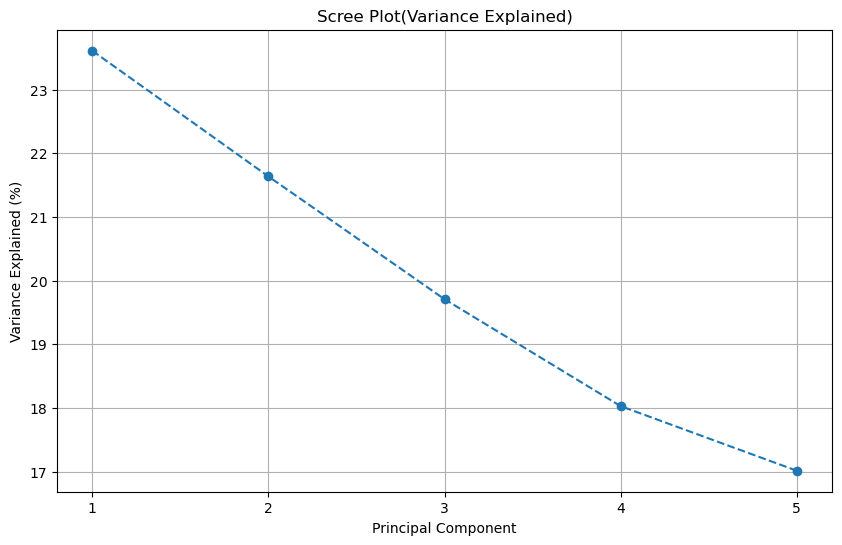

In [6]:
# Scree Plot 
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance * 100, marker='o', linestyle='--')
plt.title('Scree Plot(Variance Explained)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid()
plt.show()

PCA by use of real datafrom 5 government securities for the period of 6 months.

In [7]:
# Treasury security tickers definition.
tickers = "^GSPC", "^FVX", "^IRX","^TNX", "^TYX"
# Set DataFrame for the yield.
data = pd.DataFrame()
# Collect the historicaltreasury secuirty data.
for ticker in tickers:  
# a 6 month daily closing yields or prices  
    df = yf.download(ticker, start="2024-01-01", end="2024-07-01")     
# The 'Close' prices   
    data[ticker] = df['Close']
# creating a column named Date.
    #data.reset_index(inplace=True)
    # show the data
    print(data)
    #Save the collected data in form of CSV.
    data.to_csv('treasury_yields.csv', index=False)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


                  ^GSPC
Date                   
2024-01-02  4742.830078
2024-01-03  4704.810059
2024-01-04  4688.680176
2024-01-05  4697.240234
2024-01-08  4763.540039
...                 ...
2024-06-24  5447.870117
2024-06-25  5469.299805
2024-06-26  5477.899902
2024-06-27  5482.870117
2024-06-28  5460.479980

[124 rows x 1 columns]
                  ^GSPC   ^FVX
Date                          
2024-01-02  4742.830078  3.926
2024-01-03  4704.810059  3.891
2024-01-04  4688.680176  3.973
2024-01-05  4697.240234  4.008
2024-01-08  4763.540039  3.956
...                 ...    ...
2024-06-24  5447.870117  4.271
2024-06-25  5469.299805  4.263
2024-06-26  5477.899902  4.336
2024-06-27  5482.870117  4.301
2024-06-28  5460.479980  4.329

[124 rows x 2 columns]
                  ^GSPC   ^FVX   ^IRX
Date                                 
2024-01-02  4742.830078  3.926  5.213
2024-01-03  4704.810059  3.891  5.235
2024-01-04  4688.680176  3.973  5.228
2024-01-05  4697.240234  4.008  5.220
2024-01-0

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  ^GSPC   ^FVX   ^IRX   ^TNX
Date                                        
2024-01-02  4742.830078  3.926  5.213  3.946
2024-01-03  4704.810059  3.891  5.235  3.907
2024-01-04  4688.680176  3.973  5.228  3.991
2024-01-05  4697.240234  4.008  5.220  4.042
2024-01-08  4763.540039  3.956  5.220  4.002
...                 ...    ...    ...    ...
2024-06-24  5447.870117  4.271  5.210  4.248
2024-06-25  5469.299805  4.263  5.223  4.238
2024-06-26  5477.899902  4.336  5.230  4.316
2024-06-27  5482.870117  4.301  5.223  4.288
2024-06-28  5460.479980  4.329  5.213  4.343

[124 rows x 4 columns]
                  ^GSPC   ^FVX   ^IRX   ^TNX   ^TYX
Date                                               
2024-01-02  4742.830078  3.926  5.213  3.946  4.085
2024-01-03  4704.810059  3.891  5.235  3.907  4.056
2024-01-04  4688.680176  3.973  5.228  3.991  4.137
2024-01-05  4697.240234  4.008  5.220  4.042  4.200
2024-01-08  4763.540039  3.956  5.220  4.002  4.173
...                 ...    

DATA IMPORTATION 

In [8]:
# Import the data for analysis.
yields_data = pd.read_csv('treasury_yields.csv')  
yields_data

,^GSPC,^FVX,^IRX,^TNX,^TYX
0,4742.830078,3.926,5.213,3.946,4.085
1,4704.810059,3.891,5.235,3.907,4.056
2,4688.680176,3.973,5.228,3.991,4.137
3,4697.240234,4.008,5.220,4.042,4.200
4,4763.540039,3.956,5.220,4.002,4.173
...,...,...,...,...,...
119,5447.870117,4.271,5.210,4.248,4.378
120,5469.299805,4.263,5.223,4.238,4.372
121,5477.899902,4.336,5.230,4.316,4.447
122,5482.870117,4.301,5.223,4.288,4.427


DATA EXPLORATION

In [9]:
data.head()

,^GSPC,^FVX,^IRX,^TNX,^TYX
Date,,,,,
2024-01-02,4742.830078,3.926,5.213,3.946,4.085
2024-01-03,4704.810059,3.891,5.235,3.907,4.056
2024-01-04,4688.680176,3.973,5.228,3.991,4.137
2024-01-05,4697.240234,4.008,5.220,4.042,4.200
2024-01-08,4763.540039,3.956,5.220,4.002,4.173


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 124 entries, 2024-01-02 to 2024-06-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^GSPC   124 non-null    float64
 1   ^FVX    124 non-null    float64
 2   ^IRX    124 non-null    float64
 3   ^TNX    124 non-null    float64
 4   ^TYX    124 non-null    float64
dtypes: float64(5)
memory usage: 5.8 KB


In [11]:
data.describe()

,^GSPC,^FVX,^IRX,^TNX,^TYX
count,124.000000,124.000000,124.000000,124.000000,124.000000
mean,5121.632828,4.297137,5.228685,4.304742,4.458435
std,199.727462,0.223462,0.014987,0.194069,0.169256
min,4688.680176,3.799000,5.188000,3.863000,4.056000
25%,4999.942627,4.127000,5.218000,4.168500,4.353750
50%,5129.370117,4.298000,5.233000,4.292000,4.441500
75%,5249.955200,4.462750,5.240000,4.446000,4.574750
max,5487.029785,4.723000,5.255000,4.706000,4.820000


DATA ANALYSIS 

f) Daily yield changes computation.

In [12]:
# The daily yield changes.
yield_changes = yields_data.diff().dropna()
yield_changes

,^GSPC,^FVX,^IRX,^TNX,^TYX
1,-38.020020,-0.035,0.022,-0.039,-0.029
2,-16.129883,0.082,-0.007,0.084,0.081
3,8.560059,0.035,-0.008,0.051,0.063
4,66.299805,-0.052,0.000,-0.040,-0.027
5,-7.040039,0.023,0.010,0.017,0.012
...,...,...,...,...,...
119,-16.750000,0.000,-0.005,-0.009,-0.020
120,21.429688,-0.008,0.013,-0.010,-0.006
121,8.600098,0.073,0.007,0.078,0.075
122,4.970215,-0.035,-0.007,-0.028,-0.020


g) Principal Component -re-run.

In [13]:
#Re-run PCA
pca_real = PCA()
pca_real.fit(yield_changes)

PCA()

h) Comparison of explained variances for the real data.

In [14]:
# Each Component explained variances.
variances_real = pca_real.explained_variance_ratio_
print("Component 1 Variance explained :", variances_real[0])
print("Component 2 Variance explained :", variances_real[1])
print("Component 3 Variance explained :", variances_real[2])

Component 1 Variance explained : 0.9999910546193203
Component 2 Variance explained : 8.55511122922835e-06
Component 3 Variance explained : 3.44693458651958e-07


In [15]:
# Variance ratios in percentage.
variance_real = explained_variance * 100  
print("Component Variance Explained:")
for i, var in enumerate(variances_real):    
    print(f'Component {i + 1}: {var:.2f}%')

Component Variance Explained:
Component 1: 1.00%
Component 2: 0.00%
Component 3: 0.00%
Component 4: 0.00%
Component 5: 0.00%


Component 1 has the highest ratio of explained variance

i) Screeplot of the explained variance for each component.


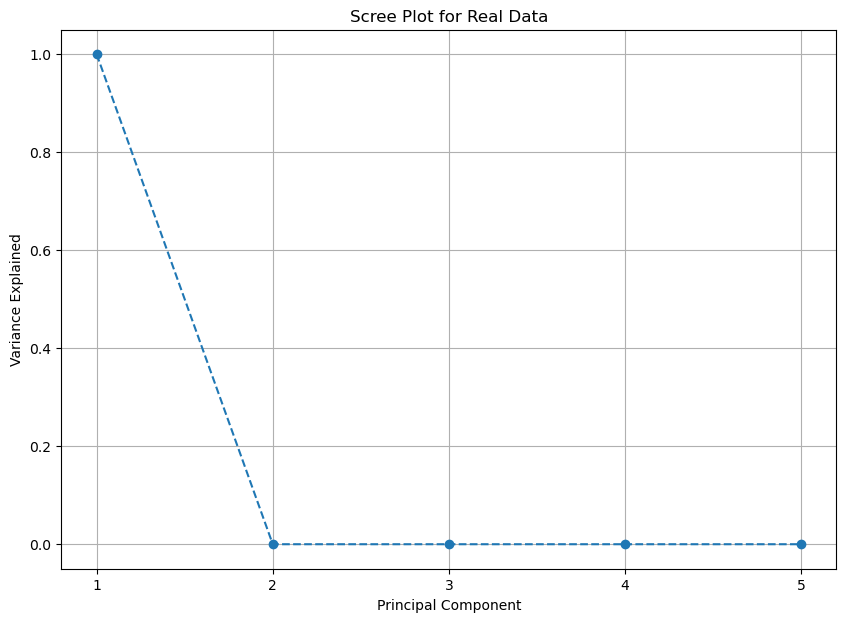

In [16]:
#Produce a Screeplot for Real Data
plt.figure(figsize=(10, 7))
plt.plot(range(1, len(variances_real) + 1), variances_real, marker='o', linestyle='--')
plt.title('Scree Plot for Real Data')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.xticks(range(1, len(variances_real) + 1))
plt.grid()
plt.show()

j) Comparison of Screeplots from government data and uncorrelated data

The scree plot from the uncorrelated data, according to the analysis, shows slightly equal variances among the components under consideration, namely Component 1: 23.61%, Component 2: 21.64%, Component 3: 19.71%, Component 4: 18.03%, and Component 5: 17.02%. In contrast, the scree plot from the real data indicates a more significant explained variance for component 1, as shown by Component 1: 0.9999910546193203, Component 2: 8.555111229228343e-06, and Component 3 V: 3.4469345865195824e-02. The drop-off by components 2 and 3 is quick. This indicates that the primary component provides more insight into the composition of the data being utilized.

References

Weston, J., & Moore, S. (2002). Eigenvectors, Eigenvalues, and PCA. In Kluwer Academic Publishers.

Jolliffe, I. T. (2002). Principal Component Analysis. Springer Series in Statistics.